# MLP Classification #
Arhan Erdogan

#### Imports ####

In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#### Loaded cleaned dataset ####

In [54]:
script_dir = os.getcwd()
rel_path = "intermediate"

dataset = pd.read_csv(os.path.join(script_dir, rel_path, "CLEAN_data_injection_moulding.csv"))

#### Feature selection might change ####

Excluding cycle time (ZUs) as it dominates the model. Selected features include are injection time (ZSx), cushion volume (ACPx), dosing time (ZDx), ejection time (ZEx), energy consumption (GEx) and temperature measures (H16x and H10x).

In [ ]:
# features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'GEx [kWh]', 'H16x [°C]', 'H10x [°C]']
#ZUs [s] excluded, with it F1: 0.95
features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'APHu [bar]', 'GEx [kWh]', 'GPx [kW]', 'HPx [kW]', 'HEx [kWh]', 'MPx [kW]', 'ESPx [kWh/kg]', 'H16x [°C]', 'H15x [°C]', 'H10x [°C]', 'H12x [°C]', 'H9x [°C]', 'H11x [°C]']

X = dataset[features]
y = dataset['ASZ [Sch]']

7


#### Splitting and Scaling Data ####

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Training MLP basic and without balancing ####

In [57]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
%store mlp
mlp.fit(X_train_scaled, y_train)

Stored 'mlp' (MLPClassifier)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


#### Evaluate Basic Model ####

In [58]:
y_pred = mlp.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       933
           1       0.80      0.42      0.55        38

    accuracy                           0.97       971
   macro avg       0.89      0.71      0.77       971
weighted avg       0.97      0.97      0.97       971



#### Plot Confusion Matrix (Basic Model) ####

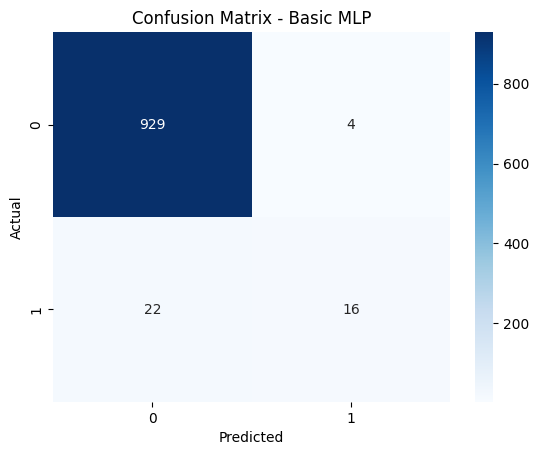

In [59]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Basic MLP')
plt.show()

#### Apply SMOTE to Handle Class Imbalance ####

The dataset has severe class imbalance (~933 good parts vs ~38 scrap). We use SMOTE to oversample the minority class in the training data.

In [60]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {sum(y_train == 1)} scrap samples')
print(f'After SMOTE: {sum(y_train_res == 1)} scrap samples')

Before SMOTE: 125 scrap samples
After SMOTE: 3758 scrap samples


#### Train MLP with Balanced Data ####

In [61]:
mlp_balanced = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)
%store mlp_balanced
mlp_balanced.fit(X_train_res, y_train_res)



Stored 'mlp_balanced' (MLPClassifier)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


#### Evaluate Balanced Model ####

In [62]:
y_pred_balanced = mlp_balanced.predict(X_test_scaled)
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       933
           1       0.54      0.87      0.67        38

    accuracy                           0.97       971
   macro avg       0.77      0.92      0.82       971
weighted avg       0.98      0.97      0.97       971



#### Plot Confusion Matrix (Balanced Model) ####

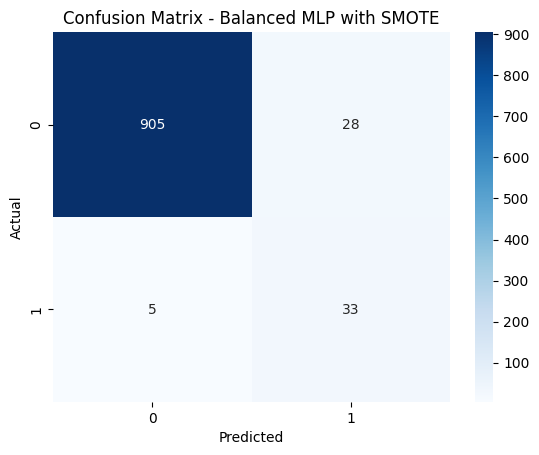

In [63]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Balanced MLP with SMOTE')
plt.show()

#### Hyperparameter Tuning - Testing Different Architectures ####

We test different hidden layer configurations to find the optimal architecture.

In [64]:
architectures = [
    (32,),
    (64,),
    (128,),
    (64, 32),
    (100, 50),
    (128, 64, 32)
]

results = []

for arch in architectures:
    mlp_test = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
    )
    
    mlp_test.fit(X_train_res, y_train_res)
    y_pred_test = mlp_test.predict(X_test_scaled)
    
    report = classification_report(y_test, y_pred_test, output_dict=True)
    
    results.append({
        'architecture': arch,
        'accuracy': report['accuracy'],
        'scrap_precision': report['1']['precision'],
        'scrap_recall': report['1']['recall'],
        'scrap_f1': report['1']['f1-score']
    })
    
    print(f"Architecture {arch}:")
    print(f"  Accuracy: {report['accuracy']:.3f}")
    print(f"  Scrap Recall: {report['1']['recall']:.3f}")
    print(f"  Scrap F1: {report['1']['f1-score']:.3f}")
    print()

Architecture (32,):
  Accuracy: 0.959
  Scrap Recall: 0.868
  Scrap F1: 0.623

Architecture (64,):
  Accuracy: 0.958
  Scrap Recall: 0.842
  Scrap F1: 0.610

Architecture (128,):
  Accuracy: 0.966
  Scrap Recall: 0.868
  Scrap F1: 0.667

Architecture (64, 32):
  Accuracy: 0.979
  Scrap Recall: 0.842
  Scrap F1: 0.762

Architecture (100, 50):
  Accuracy: 0.978
  Scrap Recall: 0.737
  Scrap F1: 0.727

Architecture (128, 64, 32):
  Accuracy: 0.977
  Scrap Recall: 0.684
  Scrap F1: 0.703



#### Visualize Architecture Performance ####

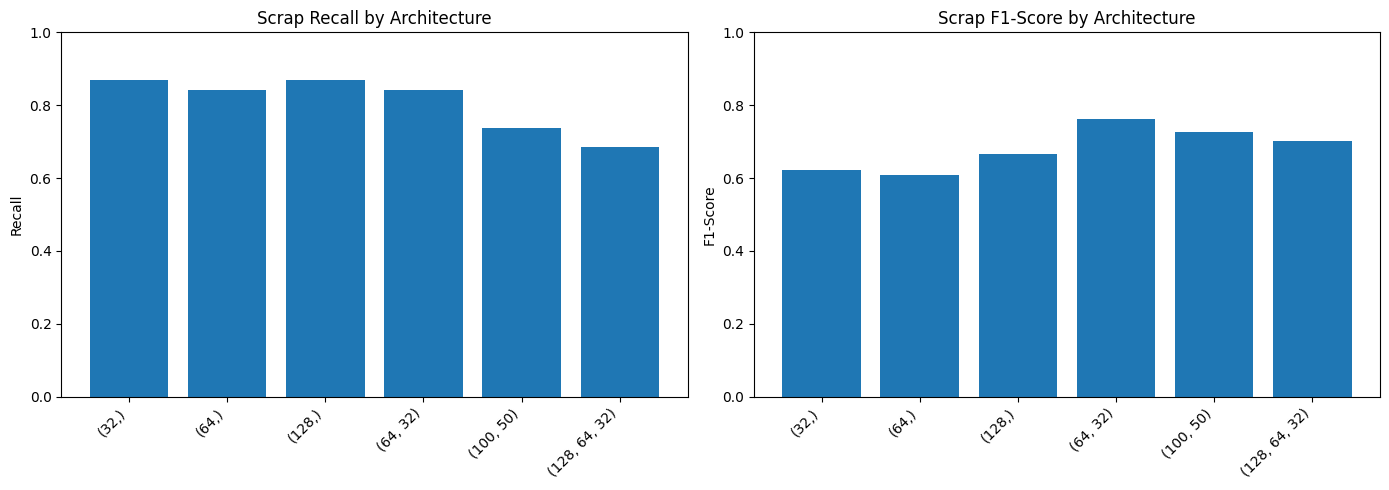

In [65]:
results_df = pd.DataFrame(results)
results_df['arch_label'] = results_df['architecture'].astype(str)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(range(len(results_df)), results_df['scrap_recall'])
ax[0].set_xticks(range(len(results_df)))
ax[0].set_xticklabels(results_df['arch_label'], rotation=45, ha='right')
ax[0].set_ylabel('Recall')
ax[0].set_title('Scrap Recall by Architecture')
ax[0].set_ylim([0, 1])

ax[1].bar(range(len(results_df)), results_df['scrap_f1'])
ax[1].set_xticks(range(len(results_df)))
ax[1].set_xticklabels(results_df['arch_label'], rotation=45, ha='right')
ax[1].set_ylabel('F1-Score')
ax[1].set_title('Scrap F1-Score by Architecture')
ax[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

#### Training History (Loss Curve) ####

Visualize how the model's loss decreased during training.

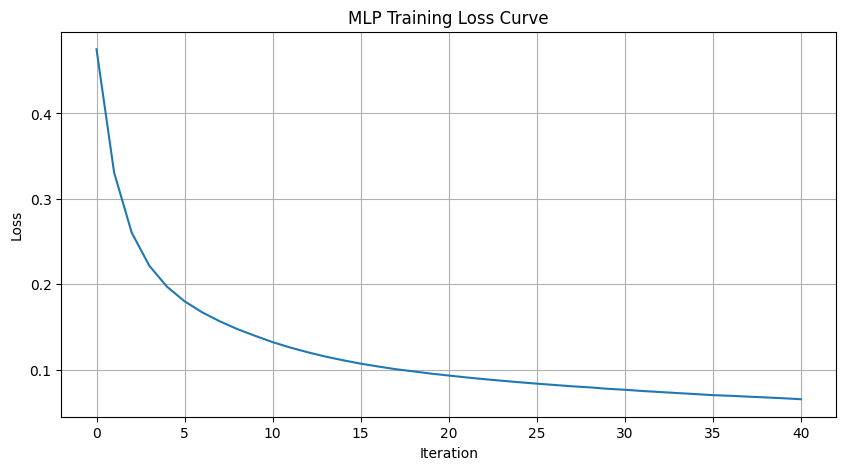

Final training loss: 0.0653
Number of iterations: 41


In [66]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_balanced.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Training Loss Curve')
plt.grid(True)
plt.show()

print(f"Final training loss: {mlp_balanced.loss_:.4f}")
print(f"Number of iterations: {mlp_balanced.n_iter_}")

#### Threshold optimization ####

In [67]:
y_proba = mlp_balanced.predict_proba(X_test_scaled)[:, 1]
# [:, 1] gets probability of class 1 like scrapos

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_thresh, output_dict=True)
    results.append({
        'threshold': threshold,
        'f1_score': report['1']['f1-score'],
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'accuracy': report['accuracy']
    })

    print(f"Threshold: {threshold:.2f} | F1: {report['1']['f1-score']:.3f} | "
          f"Precision: {report['1']['precision']:.3f} | Recall: {report['1']['recall']:.3f}")

# Convert to DataFrame for easy analysis
results_df = pd.DataFrame(results)

# Find best threshold
best_idx = results_df['f1_score'].idxmax()
best_threshold = results_df.loc[best_idx, 'threshold']
best_f1 = results_df.loc[best_idx, 'f1_score']

print(f"best threshold = {best_threshold:.2f} with F1 score: {best_f1:.3f}")

Threshold: 0.10 | F1: 0.393 | Precision: 0.248 | Recall: 0.947
Threshold: 0.15 | F1: 0.442 | Precision: 0.288 | Recall: 0.947
Threshold: 0.20 | F1: 0.496 | Precision: 0.340 | Recall: 0.921
Threshold: 0.25 | F1: 0.543 | Precision: 0.385 | Recall: 0.921
Threshold: 0.30 | F1: 0.609 | Precision: 0.455 | Recall: 0.921
Threshold: 0.35 | F1: 0.614 | Precision: 0.461 | Recall: 0.921
Threshold: 0.40 | F1: 0.631 | Precision: 0.479 | Recall: 0.921
Threshold: 0.45 | F1: 0.660 | Precision: 0.523 | Recall: 0.895
Threshold: 0.50 | F1: 0.667 | Precision: 0.541 | Recall: 0.868
Threshold: 0.55 | F1: 0.673 | Precision: 0.550 | Recall: 0.868
Threshold: 0.60 | F1: 0.660 | Precision: 0.554 | Recall: 0.816
Threshold: 0.65 | F1: 0.652 | Precision: 0.569 | Recall: 0.763
Threshold: 0.70 | F1: 0.659 | Precision: 0.596 | Recall: 0.737
Threshold: 0.75 | F1: 0.684 | Precision: 0.659 | Recall: 0.711
Threshold: 0.80 | F1: 0.693 | Precision: 0.703 | Recall: 0.684
Threshold: 0.85 | F1: 0.685 | Precision: 0.714 | Recall

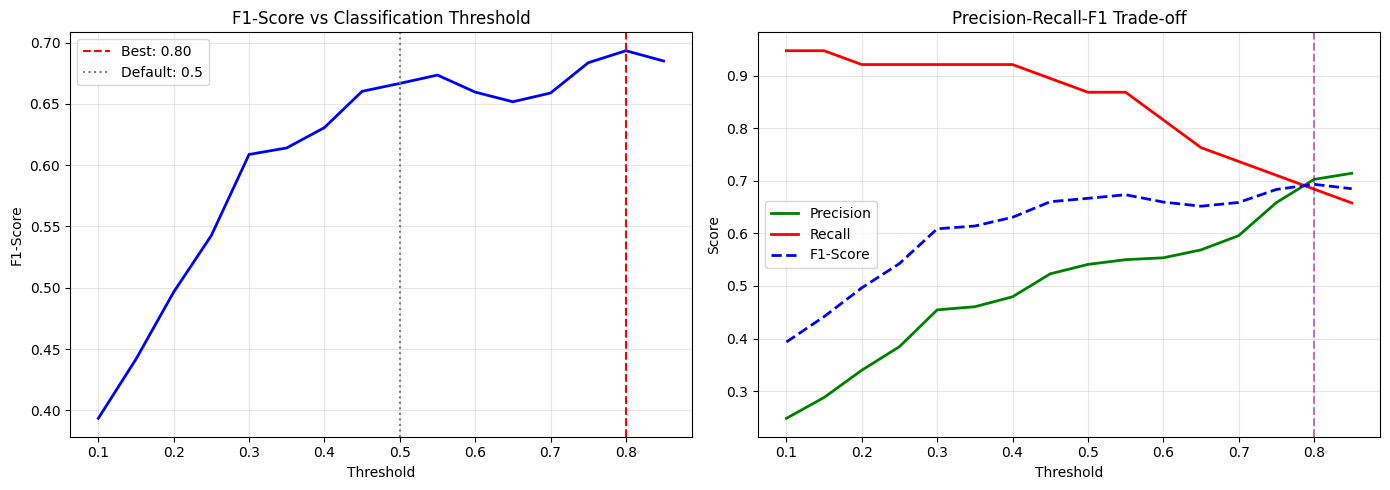

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1-Score vs Threshold
axes[0].plot(results_df['threshold'], results_df['f1_score'], 'b-', linewidth=2)
axes[0].axvline(best_threshold, color='r', linestyle='--', label=f'Best: {best_threshold:.2f}')
axes[0].axvline(0.5, color='gray', linestyle=':', label='Default: 0.5')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('F1-Score vs Classification Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision-Recall Trade-off
axes[1].plot(results_df['threshold'], results_df['precision'], 'g-', label='Precision', linewidth=2)
axes[1].plot(results_df['threshold'], results_df['recall'], 'r-', label='Recall', linewidth=2)
axes[1].plot(results_df['threshold'], results_df['f1_score'], 'b--', label='F1-Score', linewidth=2)
axes[1].axvline(best_threshold, color='purple', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision-Recall-F1 Trade-off')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Performance with optimized threshold
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       933
           1       0.70      0.68      0.69        38

    accuracy                           0.98       971
   macro avg       0.84      0.84      0.84       971
weighted avg       0.98      0.98      0.98       971



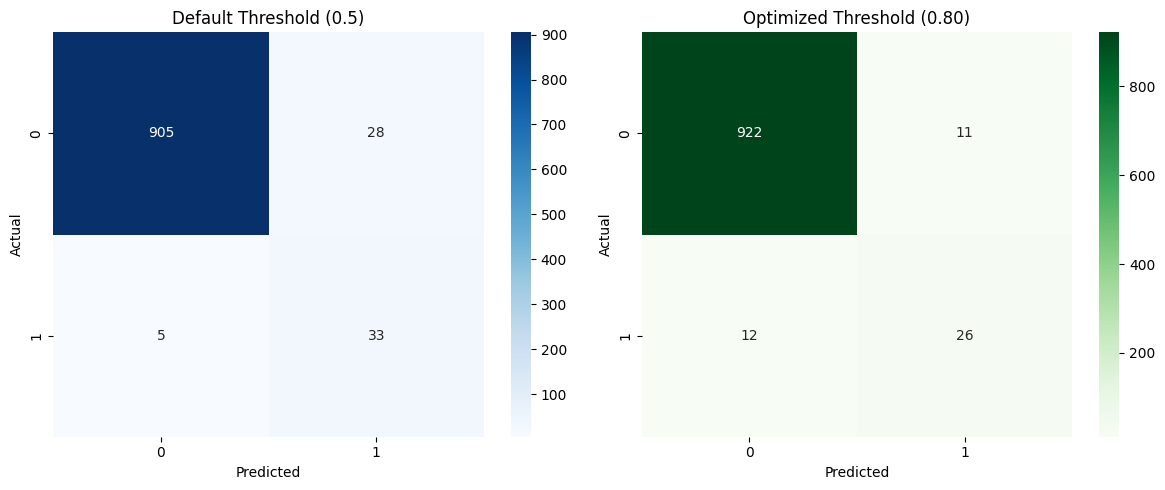

In [69]:
y_pred_optimized = (y_proba >= best_threshold).astype(int)

print("Performance with optimized threshold")
print(classification_report(y_test, y_pred_optimized))

# confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_default = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Default Threshold (0.5)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_optimized = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Optimized Threshold ({best_threshold:.2f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
